In [1]:
import uproot
import pandas as pd
import numpy as np
import glob


In [2]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [12]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_Kspip_loose_v7_250228"
cm_elements = ["Kshp_13_had_4S_off_v1", "Kshp_13_had_4S_v3", "Kshp_23_had_4S_off_v1", "Kshp_23_had_4S_v1", "Kshp_23_had_5Sscan_10657_v1", "Kshp_23_had_5Sscan_10706_v1",\
               "Kshp_23_had_5Sscan_10751_v1", "Kshp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_gg"
tree_name = "Ks"
file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/apply_bdt/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','BDT']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [13]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [14]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,5.275257e+06,5.275257e+06,5.275257e+06,5.275257e+06,5.275257e+06,5.275257e+06
mean,1.845698e+00,6.704498e-02,3.317746e-01,1.457766e+00,-1.829863e-03,3.812840e-01
std,1.307484e-01,5.533845e-01,4.977558e-01,1.056422e+00,9.999984e-01,2.948112e-01
min,1.600000e+00,-9.999974e-01,-9.044896e-01,4.000000e-01,-1.000000e+00,6.982111e-07
25%,1.740400e+00,-4.228716e-01,-4.569331e-02,5.587125e-01,-1.000000e+00,1.354333e-01
50%,1.862056e+00,9.331882e-02,4.564721e-01,1.004847e+00,-1.000000e+00,2.831472e-01
75%,1.941586e+00,5.624248e-01,7.679440e-01,2.241368e+00,1.000000e+00,6.062924e-01
max,2.100000e+00,9.999999e-01,9.794338e-01,1.573749e+01,1.000000e+00,9.969110e-01


In [15]:
df_proc13 = df_proc13.query('Dp_M> 1.80 & Dp_M<1.93')


In [16]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,1.897209e+06,1.897209e+06,1.897209e+06,1.897209e+06,1.897209e+06,1.897209e+06
mean,1.865768e+00,7.738835e-02,3.252788e-01,1.574705e+00,-2.511584e-03,4.601900e-01
std,3.090990e-02,5.482998e-01,4.967808e-01,1.067540e+00,9.999971e-01,3.228984e-01
min,1.800000e+00,-9.999974e-01,-8.999475e-01,4.000000e-01,-1.000000e+00,9.740133e-07
25%,1.846620e+00,-4.030764e-01,-5.835181e-02,6.131080e-01,-1.000000e+00,1.638694e-01
50%,1.868786e+00,1.081797e-01,4.441723e-01,1.269720e+00,-1.000000e+00,3.779388e-01
75%,1.882063e+00,5.648539e-01,7.639325e-01,2.360215e+00,1.000000e+00,7.951592e-01
max,1.930000e+00,9.999932e-01,9.794338e-01,1.250819e+01,1.000000e+00,9.969110e-01


In [17]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
BDT                False
dtype: bool


In [18]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p"
cm_elements = ["MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1", "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1", "MCrd_Ks_mori_off_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_gg"
tree_name = "Ks"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/apply_bdt/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','BDT']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [19]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [20]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,2.182180e+07,2.182180e+07,2.182180e+07,2.182180e+07,2.182180e+07,2.182180e+07
mean,1.840251e+00,5.472330e-02,3.156088e-01,1.497440e+00,2.485130e-04,3.659076e-01
std,1.315147e-01,5.467403e-01,4.960346e-01,1.075483e+00,1.000000e+00,2.881938e-01
min,1.600000e+00,-9.999998e-01,-9.083980e-01,4.000000e-01,-1.000000e+00,3.609499e-08
25%,1.732693e+00,-4.265903e-01,-6.705533e-02,5.801026e-01,-1.000000e+00,1.299146e-01
50%,1.851595e+00,7.119965e-02,4.299720e-01,1.042564e+00,1.000000e+00,2.702297e-01
75%,1.937563e+00,5.432154e-01,7.523776e-01,2.307029e+00,1.000000e+00,5.670454e-01
max,2.100000e+00,9.999999e-01,9.814150e-01,3.003157e+01,1.000000e+00,9.976612e-01


In [21]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.80 & Dp_M<1.93')


In [22]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,7.442793e+06,7.442793e+06,7.442793e+06,7.442793e+06,7.442793e+06,7.442793e+06
mean,1.864847e+00,6.139218e-02,3.112089e-01,1.598821e+00,6.157635e-04,4.286325e-01
std,3.201836e-02,5.441914e-01,4.957111e-01,1.084047e+00,9.999999e-01,3.162708e-01
min,1.800000e+00,-9.999998e-01,-9.083980e-01,4.000001e-01,-1.000000e+00,1.768707e-07
25%,1.842601e+00,-4.142390e-01,-7.578501e-02,6.255830e-01,-1.000000e+00,1.498800e-01
50%,1.868206e+00,8.055304e-02,4.215879e-01,1.275905e+00,1.000000e+00,3.332814e-01
75%,1.883244e+00,5.448956e-01,7.502628e-01,2.406854e+00,1.000000e+00,7.301975e-01
max,1.930000e+00,9.999999e-01,9.791014e-01,2.252845e+01,1.000000e+00,9.976612e-01


In [23]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
BDT                False
dtype: bool


In [24]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


/home/jykim/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3378: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  exec(code_obj, self.user_global_ns, self.user_ns)


In [25]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


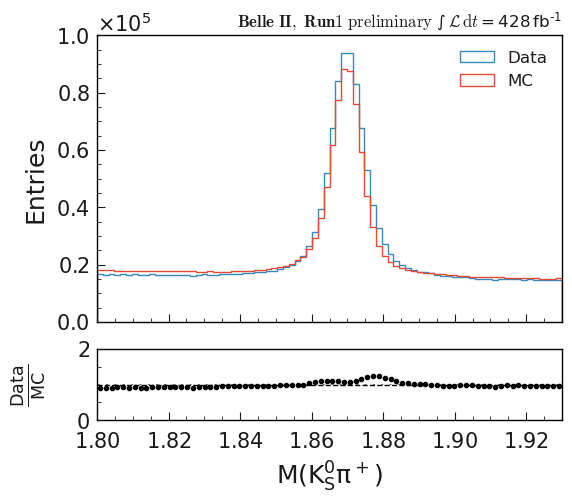

In [28]:
name = "Dp_M"
category = "category"
xlabel = r"$M(K_S^0 \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.80,1.93)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{ref_tree}_{name}_no_bdt.png", bbox_inches="tight")

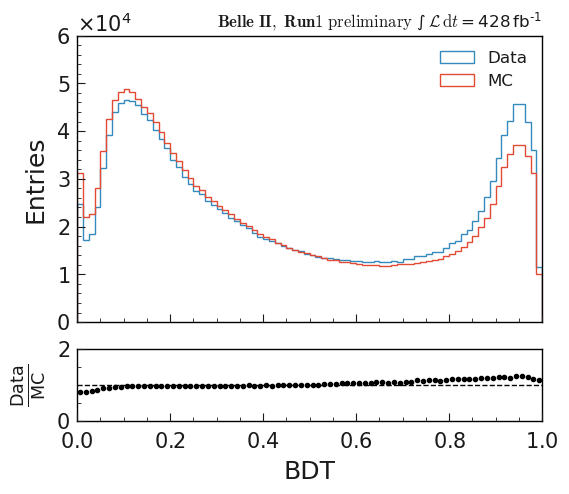

In [29]:
name = "BDT"
category = "category"
xlabel = r"BDT"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (0,1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{ref_tree}_{name}_no_bdt.png", bbox_inches="tight")